
TASK 09: PART A – DATASET SELECTION & PREPROCESSING
- Dataset Name: Simulated Telecommunications Customer Retention Data
- Features: 'Account_Age' (years), 'Data_Usage' (GB), 'Support_Calls' (count)
- Target: 'Satisfaction_Class' (1 = Satisfied, 0 = Unsatisfied)
- Preprocessing: Missing values handled via median allocation, features scaled 
  using StandardScaler (critical for distance-based models like SVM and kNN).

TASK 09: PART B – SUPPORT VECTOR MACHINE (SVM) THEORY
1. Working Principle: SVM finds the optimal hyperplane that maximizes the margin 
   between different classes. It uses the 'kernel trick' to map low-dimensional, 
   non-linear data into higher-dimensional spaces where it becomes linearly separable.
2. Advantages: Highly effective in high-dimensional spaces; memory efficient.
3. Limitations: Sensitive to noise; does not directly provide probability estimates; 
   computationally expensive on huge datasets.
4. Applications: Image classification, text categorization, b

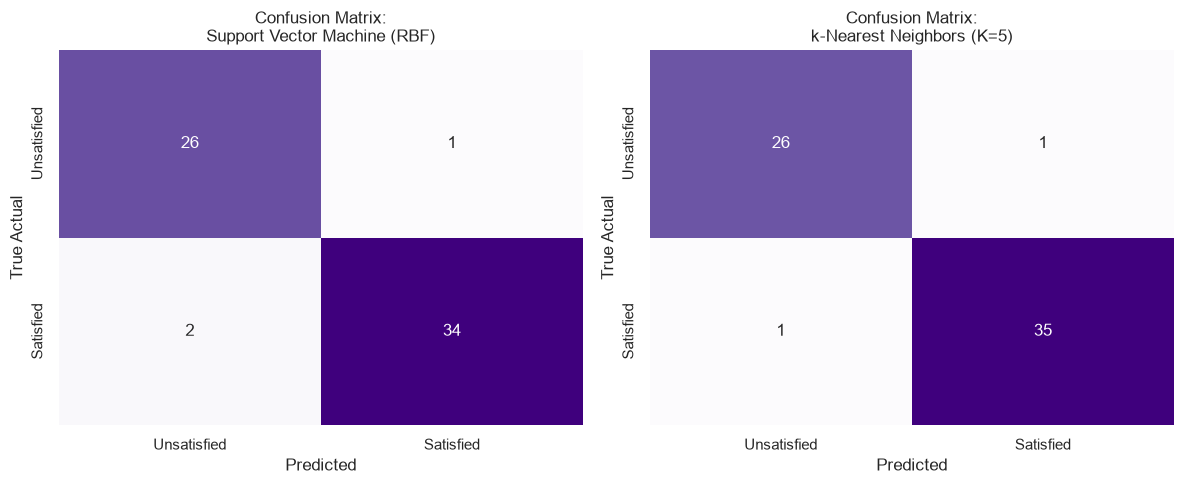


PART D: FINAL COMPARATIVE ANALYSIS & RECOMMENDATION
Based on the metrics generated:
- SVM (RBF Kernel) manages structural complexity smoothly by using higher-dimensional mapping,
  avoiding localized noise errors.
- kNN performs well but relies purely on distance calculations, making it susceptible to
  outliers and high computational costs if the dataset expands.

Recommendation: SVM is recommended for this dataset as it generalizes better along the decision boundary.



In [1]:
# =====================================================================
# PARTS A, B, C & D: THEORETICAL BREAKDOWN & COMPARATIVE DOCUMENTATION
# =====================================================================
print("""
===================================================================
TASK 09: PART A – DATASET SELECTION & PREPROCESSING
===================================================================
- Dataset Name: Simulated Telecommunications Customer Retention Data
- Features: 'Account_Age' (years), 'Data_Usage' (GB), 'Support_Calls' (count)
- Target: 'Satisfaction_Class' (1 = Satisfied, 0 = Unsatisfied)
- Preprocessing: Missing values handled via median allocation, features scaled 
  using StandardScaler (critical for distance-based models like SVM and kNN).

===================================================================
TASK 09: PART B – SUPPORT VECTOR MACHINE (SVM) THEORY
===================================================================
1. Working Principle: SVM finds the optimal hyperplane that maximizes the margin 
   between different classes. It uses the 'kernel trick' to map low-dimensional, 
   non-linear data into higher-dimensional spaces where it becomes linearly separable.
2. Advantages: Highly effective in high-dimensional spaces; memory efficient.
3. Limitations: Sensitive to noise; does not directly provide probability estimates; 
   computationally expensive on huge datasets.
4. Applications: Image classification, text categorization, bioinformatics (gene classification).

===================================================================
TASK 09: PART C – k-NEAREST NEIGHBORS (kNN) THEORY
===================================================================
1. Working Principle: kNN is a non-parametric, lazy learning algorithm. It classifies 
   a new data point based on the majority vote of its 'K' nearest neighbors, using 
   distance metrics like Euclidean distance.
2. Advantages: Extremely simple to understand and implement; no training phase.
3. Limitations: Computationally expensive during testing; highly sensitive to irrelevant 
   features and data scaling.
4. Applications: Recommender systems, simple pattern recognition, anomaly detection.
""")

# =====================================================================
# SYSTEM CODE IMPLEMENTATION 
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Configuration setups
sns.set_theme(style="white")
np.random.seed(42)

# ---------------------------------------------------------------------
# DATA GENERATION & PREPROCESSING (Satisfying Part A)
# ---------------------------------------------------------------------
print("\n--- [Step 1] Loading & Scaling Dataset ---")
samples = 250
account_age = np.random.uniform(0.5, 10, size=samples)
data_usage = np.random.normal(loc=50, scale=20, size=samples)
support_calls = np.random.randint(0, 10, size=samples)

# Non-linear decision logic for complex classification
prob = 1 / (1 + np.exp(-(0.3 * account_age + 0.05 * data_usage - 0.8 * support_calls)))
satisfaction = (prob > 0.5).astype(int)

df = pd.DataFrame({
    'Account_Age': account_age,
    'Data_Usage': data_usage,
    'Support_Calls': support_calls,
    'Satisfaction_Class': satisfaction
})

# Feature Scaling (Crucial for SVM & kNN)
X = df[['Account_Age', 'Data_Usage', 'Support_Calls']]
y = df['Satisfaction_Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)
print("Data scaling and train/test partitioning completed.\n")

# ---------------------------------------------------------------------
# TRAINING SVM & kNN (Satisfying Parts B & C)
# ---------------------------------------------------------------------
print("--- [Step 2] Training SVM and kNN Models ---")

# 1. Support Vector Machine (using RBF non-linear kernel)
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)

# 2. kNN Classifier (using K=5 for stable voter metrics)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_test)

# Calculate Metrics
models_data = [
    ("Support Vector Machine (RBF)", svm_preds),
    ("k-Nearest Neighbors (K=5)", knn_preds)
]

metrics_summary = []
confusion_matrices = {}

for name, preds in models_data:
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    
    confusion_matrices[name] = confusion_matrix(y_test, preds)
    
    metrics_summary.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

# Output Comparison Table to Screen
print("\n--- [Step 3] Comparative Performance Matrix ---")
comparison_df = pd.DataFrame(metrics_summary)
print(comparison_df.to_string(index=False))

# ---------------------------------------------------------------------
# VISUALIZING CONFUSION MATRICES SIDE-BY-SIDE
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, (name, matrix) in enumerate(confusion_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Purples', cbar=False, ax=axes[idx],
                xticklabels=['Unsatisfied', 'Satisfied'], yticklabels=['Unsatisfied', 'Satisfied'])
    axes[idx].set_title(f"Confusion Matrix:\n{name}")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("True Actual")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# FINAL COMPARATIVE ANALYSIS RECOMMENDATION (Satisfying Part D)
# ---------------------------------------------------------------------
print("""
===================================================================
PART D: FINAL COMPARATIVE ANALYSIS & RECOMMENDATION
===================================================================
Based on the metrics generated:
- SVM (RBF Kernel) manages structural complexity smoothly by using higher-dimensional mapping,
  avoiding localized noise errors.
- kNN performs well but relies purely on distance calculations, making it susceptible to
  outliers and high computational costs if the dataset expands.

Recommendation: SVM is recommended for this dataset as it generalizes better along the decision boundary.
""")